Project: Lung Cancer Data Analysis and Predictive Model

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

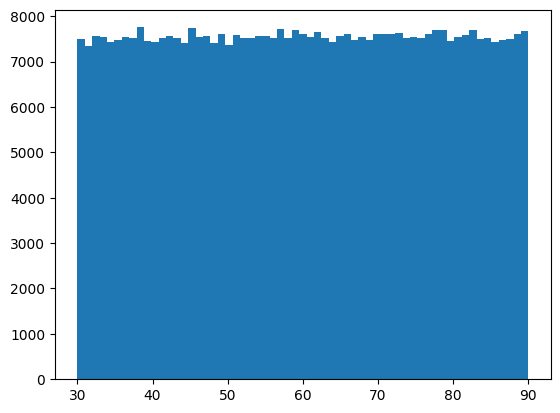

[82 66 87 51 43 78 38 59 48 44 69 32 55 74 61 46 45 30 40 31 81 49 60 47
 72 34 65 56 52 57 37 53 79 62 63 90 80 86 36 42 73 88 58 64 75 68 35 77
 76 33 70 84 71 41 83 54 67 39 89 85 50]


In [51]:
df = pd.read_csv("lung_cancer_prediction.csv")
plt.hist(df["Age"],bins=61)
plt.show()
#print(df["Age"].value_counts().sort_index())
print(df["Age"].unique())

In [52]:
df.columns

Index(['Country', 'Age', 'Gender', 'Smoking_Status', 'Second_Hand_Smoke',
       'Air_Pollution_Exposure', 'Occupation_Exposure', 'Rural_or_Urban',
       'Socioeconomic_Status', 'Healthcare_Access', 'Insurance_Coverage',
       'Screening_Availability', 'Stage_at_Diagnosis', 'Cancer_Type',
       'Mutation_Type', 'Treatment_Access', 'Clinical_Trial_Access',
       'Language_Barrier', 'Mortality_Risk', '5_Year_Survival_Probability',
       'Delay_in_Diagnosis', 'Family_History', 'Indoor_Smoke_Exposure',
       'Tobacco_Marketing_Exposure', 'Final_Prediction'],
      dtype='object')

In [103]:
class DataHandler:

    def __init__(self,filepath):
        self.filepath = filepath
        self.df = None
        

    #load data
    def load(self):
        import pandas as pd
        self.df = pd.read_csv(self.filepath, keep_default_na=False)
        #keep_default_na=False is here so that "None" in the dataset isn't counted as a missing value


    #clean data
    def clean(self):
        #remove duplicate datapoints
        self.df.drop_duplicates(inplace=True)

        #check for missing datapoints
        print("Number of missing datapoints: ", self.df.isnull().sum())
        


    #convert all categorical variables into discrete ordered/unordered values
    def transform(self, mapping = None):
        #loop through columns to adjust for ordered values
        for col in self.df:
            if col in mapping:
                self.df[col] = self.df[col].map(mapping)
                
                #change column from object to float so that it is unaffected by get_dummies
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')
                
        
        #convert all remaining object columns into unordered values
        self.df = pd.get_dummies(self.df,drop_first=True)
       

    #condense n values into m<n bins
    def bin_variable(self,column,bins,labels):
        if column in self.df:
            self.df[column+"_Bin"] = pd.cut(self.df[column],bins=bins,labels=labels,include_lowest=True)
            

    #seperate target variable from the rest of the dataset
    def set_target(self,target):
        self.y = self.df[target]
        self.x = self.df.drop(columns=[target])


    #return cleaned data
    def get_data(self):
        return self.df.copy()


    #return x
    def get_variables(self):
        return self.x.copy()
    
    
    #return y
    def get_target(self):
        return self.y.copy()
    

    #DELETE BEFORE SUBMISSION
    #FOR DEBUGGING PURPOSES ONLY
    def diagnostic(self):
        #print(self.df.dtypes)
        #print(self.df.columns)
        pass

In [ ]:
class DataVisualizer:

    def __init__(self):
        pass

In [104]:
lungCancerData = DataHandler("lung_cancer_prediction.csv")
lungCancerData.load()
lungCancerData.clean()

#these variables have to be ordered in the analysis
lungMap = {'Air_Pollution_Exposure': {'Low':1, 'Medium':2, 'High':3},
            'Socioeconomic_Status': {'Low':1, 'Middle':2, 'High':3},
            'Stage_at_Diagnosis': {'I':1, 'II':2, 'III':3, 'IV':4},
            }

#convert data types from dataset to booleans for analysis
lungCancerData.transform(lungMap)

#add a bin for age so we can make an analysis based on age groups
lungCancerData.bin_variable("Age",[29,45,60,75,91],[1,2,3,4])


Number of missing datapoints:  Country                        0
Age                            0
Gender                         0
Smoking_Status                 0
Second_Hand_Smoke              0
Air_Pollution_Exposure         0
Occupation_Exposure            0
Rural_or_Urban                 0
Socioeconomic_Status           0
Healthcare_Access              0
Insurance_Coverage             0
Screening_Availability         0
Stage_at_Diagnosis             0
Cancer_Type                    0
Mutation_Type                  0
Treatment_Access               0
Clinical_Trial_Access          0
Language_Barrier               0
Mortality_Risk                 0
5_Year_Survival_Probability    0
Delay_in_Diagnosis             0
Family_History                 0
Indoor_Smoke_Exposure          0
Tobacco_Marketing_Exposure     0
Final_Prediction               0
dtype: int64
